In [1]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv(r"C:\Users\matth\Downloads\Customer segementation Unzipped Data\orders.csv")

prior = pd.read_csv(r"C:\Users\matth\Downloads\Customer segementation Unzipped Data\order_products__prior.csv")

train = pd.read_csv(r"C:\Users\matth\Downloads\Customer segementation Unzipped Data\order_products__train.csv")

products = pd.read_csv(r"C:\Users\matth\Downloads\Customer segementation Unzipped Data\products.csv")

aisles = pd.read_csv(r"C:\Users\matth\Downloads\Customer segementation Unzipped Data\aisles.csv")

departments = pd.read_csv(r"C:\Users\matth\Downloads\Customer segementation Unzipped Data\departments.csv")

# Customer Segmentation: RFM and K-Means Clustering

## Data Preparation

Before constructing the RFM features and applying K-means clustering, the preprocessing steps conducted after the exploratory data analysis (EDA) were reproduced to recreate the integrated analytical dataset.

As established in the previous preprocessing stage, the prior and train order-product datasets were combined and merged with customer order information, product information, aisle information, and department information. This resulted in an integrated dataset (`preprocessed_df`), which serves as the basis for subsequent RFM feature engineering and clustering.

In [2]:
# Combine prior and train order-product datasets
order_products = pd.concat([prior, train],axis=0,ignore_index=True)

# Merge with orders table
preprocessed_df = order_products.merge(orders,on="order_id",how="left")

# Merge with products table
preprocessed_df = preprocessed_df.merge(products,on="product_id",how="left")

# Merge with aisles table
preprocessed_df = preprocessed_df.merge(aisles,on="aisle_id",how="left")

# Merge with departments table
preprocessed_df = preprocessed_df.merge(departments,on="department_id",how="left")

print("Final preprocessed dataset:")
print(preprocessed_df.isnull().sum())
print("Duplicates:", preprocessed_df.duplicated().sum())
print(preprocessed_df.shape)
preprocessed_df.head()

Final preprocessed dataset:
order_id                        0
product_id                      0
add_to_cart_order               0
reordered                       0
user_id                         0
eval_set                        0
order_number                    0
order_dow                       0
order_hour_of_day               0
days_since_prior_order    2078068
product_name                    0
aisle_id                        0
department_id                   0
aisle                           0
department                      0
dtype: int64
Duplicates: 0
(33819106, 15)


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13,baking ingredients,pantry


RFM Feature Engineering

In [3]:
# Recency: Total orders per customer
recency = orders.groupby("user_id")["order_number"].max().reset_index(name="R_total_orders")
recency.head()

,user_id,R_total_orders
0,1,11
1,2,15
2,3,13
3,4,6
4,5,5


In [4]:
# Frequency: Average days between orders
orders_f = orders[orders["order_number"] > 1]

frequency = orders_f.groupby("user_id")["days_since_prior_order"].mean().reset_index(name="F_avg_days_between_orders")
frequency.head()

,user_id,F_avg_days_between_orders
0,1,19.000000
1,2,16.285714
2,3,12.000000
3,4,17.000000
4,5,11.500000


In [5]:
# Monetary: Average products per order

# Number of products per order
order_size = preprocessed_df.groupby(["user_id", "order_id"])["product_id"].count().reset_index(name="products_per_order")

monetary = order_size.groupby("user_id")["products_per_order"].mean().reset_index(name="M_avg_products_per_order")
monetary.head()

,user_id,M_avg_products_per_order
0,1,6.363636
1,2,15.066667
2,3,7.333333
3,4,3.600000
4,5,9.200000


In [6]:
# Merge RFM features

rfm_df = recency.merge(frequency,on="user_id",how="inner")

rfm_df = rfm_df.merge(monetary,on="user_id",how="inner")

print(rfm_df.shape)
rfm_df.head()

(206209, 4)


,user_id,R_total_orders,F_avg_days_between_orders,M_avg_products_per_order
0,1,11,19.000000,6.363636
1,2,15,16.285714,15.066667
2,3,13,12.000000,7.333333
3,4,6,17.000000,3.600000
4,5,5,11.500000,9.200000


In [7]:
print(recency.shape)
print(frequency.shape)
print(monetary.shape)
print(rfm_df.shape)
print(rfm_df.isnull().sum())

(206209, 2)
(206209, 2)
(206209, 2)
(206209, 4)
user_id                      0
R_total_orders               0
F_avg_days_between_orders    0
M_avg_products_per_order     0
dtype: int64


In [8]:
rfm_df.describe()

,user_id,R_total_orders,F_avg_days_between_orders,M_avg_products_per_order
count,206209.000000,206209.000000,206209.000000,206209.000000
mean,103105.000000,16.590367,15.448686,9.984527
std,59527.555167,16.654774,6.915575,5.840846
min,1.000000,4.000000,0.000000,1.000000
25%,51553.000000,6.000000,9.814815,5.777778
50%,103105.000000,10.000000,15.000000,9.000000
75%,154657.000000,20.000000,20.625000,13.000000
max,206209.000000,100.000000,30.000000,60.500000


Feature Standardization

In [9]:
from sklearn.preprocessing import StandardScaler

# Select RFM features
rfm_features = rfm_df[["R_total_orders", "F_avg_days_between_orders", "M_avg_products_per_order"]]

# Standardize features
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

# Keep user_id
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm_features.columns)

rfm_scaled_df["user_id"] = rfm_df["user_id"]

rfm_scaled_df.head()

,R_total_orders,F_avg_days_between_orders,M_avg_products_per_order,user_id
0,-0.335662,0.513525,-0.619927,1
1,-0.095490,0.121035,0.870106,2
2,-0.215576,-0.498685,-0.453907,3
3,-0.635877,0.224322,-1.093085,4
4,-0.695920,-0.570986,-0.134318,5


In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Features for clustering (without user_id)
cluster_features = rfm_scaled_df[
    [
        "R_total_orders",
        "F_avg_days_between_orders",
        "M_avg_products_per_order"
    ]
]

# Store results
inertia = []
silhouette_scores = []

# Range of k values
k_range = range(2, 11)

for k in k_range:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(
        cluster_features
    )
    
    # Elbow metric
    inertia.append(
        kmeans.inertia_
    )
    
    # Silhouette score
    silhouette_scores.append(
        silhouette_score(
            cluster_features,
            cluster_labels
        )
    )

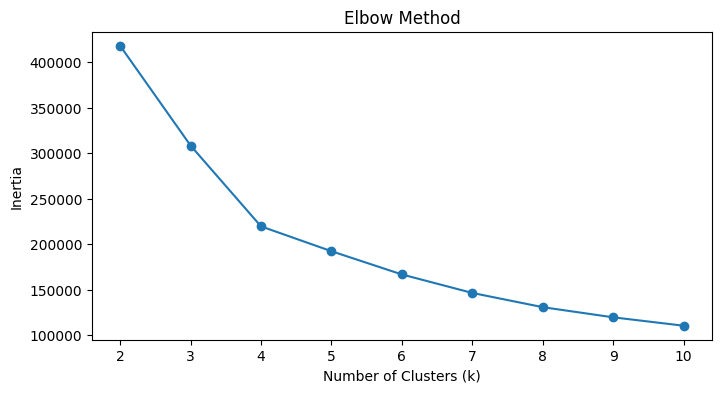

In [11]:
plt.figure(figsize=(8,4))

plt.plot(
    k_range,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

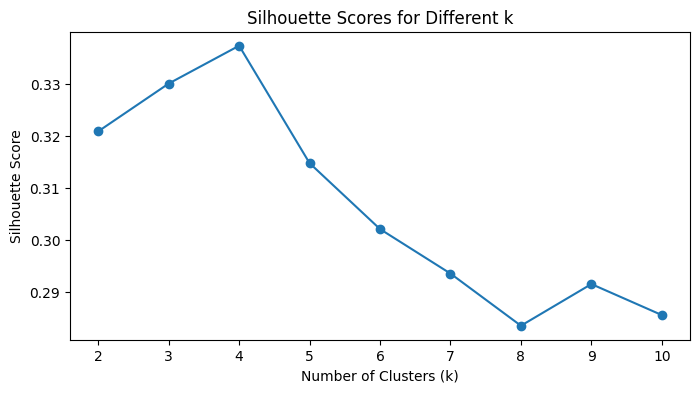

In [12]:
plt.figure(figsize=(8,4))

plt.plot(
    k_range,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Different k")

plt.show()

In [13]:
import pickle

results = {
    "inertia": inertia,
    "silhouette_scores": silhouette_scores,
    "k_range": list(k_range)
}

with open("clustering_results.pkl", "wb") as f:
    pickle.dump(results, f)

morgen:

In [ ]:
import pickle

with open("clustering_results.pkl", "rb") as f:
    results = pickle.load(f)

inertia = results["inertia"]
silhouette_scores = results["silhouette_scores"]
k_range = results["k_range"]